In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset as TorchDataset

# Chargement des données


In [4]:
df = pd.read_csv('Financial_Sentiment.csv')
texts = df['Sentence'].astype(str).tolist()
labels = df['Sentiment'].tolist()

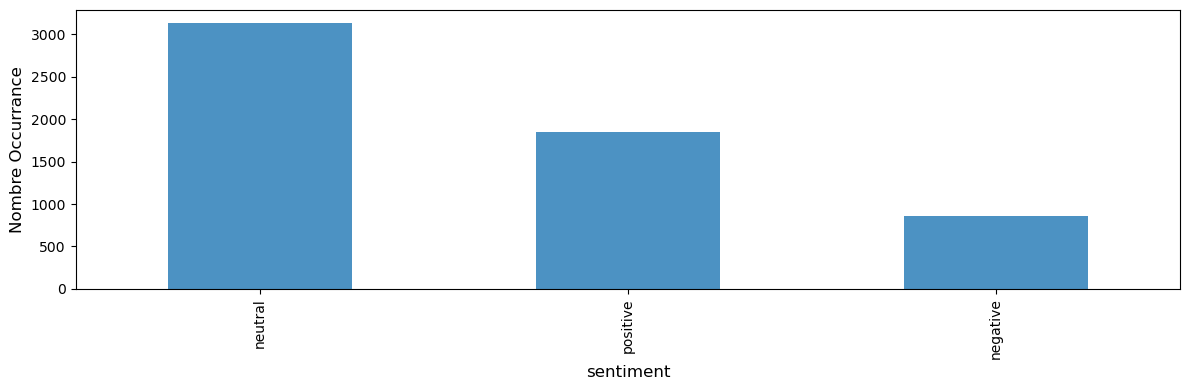

In [5]:
nombre_label = df['Sentiment'].value_counts()
plt.figure(figsize=(12,4))
nombre_label.plot(kind='bar', alpha=0.8)
plt.ylabel('Nombre Occurrance', fontsize=12)
plt.xlabel('sentiment', fontsize=12)
plt.tight_layout()
plt.show()


## Encodage labels


In [6]:
label_encoder = LabelEncoder()
labels_int = label_encoder.fit_transform(labels)
class_names = label_encoder.classes_  #['negative', 'neutral', 'positive'}

## Class weights pour déséquilibre


In [7]:
class_weights = compute_class_weight('balanced', classes=np.unique(labels_int), y=labels_int)
class_weights = torch.tensor(class_weights, dtype=torch.float)

##  Nettoyage texte 

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " <URL> ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_texts = [clean_text(t) for t in texts]

## Split train/test


In [11]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    cleaned_texts, labels_int, test_size=0.2, random_state=42, stratify=labels_int
)

# Tokenizer FinBERT
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')

## Préparation encodings


In [12]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')

## Custom PyTorch Dataset


In [13]:
class CustomDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(train_encodings, train_labels)
test_dataset = CustomDataset(test_encodings, test_labels)

## Modèle FinBERT


In [14]:
model = BertForSequenceClassification.from_pretrained('ProsusAI/finbert', num_labels=3)

## Custom loss avec class weights


In [15]:
def compute_loss(model, inputs, return_outputs=False, num_items_in_batch=None):
    labels = inputs.get("labels")
    outputs = model(**inputs)
    logits = outputs.get("logits")
    loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
    loss = loss_fct(logits.view(-1, model.num_labels), labels.view(-1))
    return (loss, outputs) if return_outputs else loss


### Override la loss dans Trainer


In [16]:
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        return compute_loss(model, inputs, return_outputs, num_items_in_batch)

### Arguments d'entraînement


In [17]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,  
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',  
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False
)


# Trainer


In [ ]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset  
)

# Entraînement
trainer.train()

C:\Users\HP\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,0.429600,0.569310


C:\Users\HP\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
history = trainer.state.log_history
train_loss = [log['loss'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
epochs = range(1, len(train_loss) + 1)

history = trainer.state.log_history

### Extraction avec epochs 


In [ ]:
train_losses = []
train_epochs = []
eval_losses = []
eval_epochs = []

for log in history:
    if 'loss' in log and 'epoch' in log:
        train_losses.append(log['loss'])
        train_epochs.append(log['epoch'])
    if 'eval_loss' in log and 'epoch' in log:
        eval_losses.append(log['eval_loss'])
        eval_epochs.append(log['epoch'])


In [ ]:
plt.plot(train_epochs, train_losses, label='train_loss')
plt.plot(eval_epochs, eval_losses, label='val_loss')
plt.title('Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()


### Évaluation sur test


In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
trainer.save_model("finbert_finetuned")
tokenizer.save_pretrained("finbert_finetuned")
